## **Install Dependencies**

In [ ]:
import subprocess, sys

def pip(*args):
    r = subprocess.run(
        [sys.executable,"-m","pip","install","-q","--no-cache-dir",*args],
        capture_output=True, text=True
    )
    if r.returncode != 0:
        print(f"pip error:\n{r.stderr[-800:]}")
        raise RuntimeError("pip failed")

print("1/4  numpy + scipy...")
pip("numpy>=2.0.0,<3.0", "scipy>=1.14.0")

print("2/4  huggingface_hub...")
pip("huggingface_hub>=0.24.0,<1.0")

print("3/4  diffusers stack...")
pip("diffusers==0.32.2","transformers==4.46.3",
    "accelerate==0.34.2","safetensors>=0.4.3")

print("4/4  utilities...")
pip("pandas>=2.2.0","Pillow>=10.0,<13.0",
    "tqdm>=4.65","matplotlib>=3.8","seaborn>=0.13")

print()
print("Done. → Runtime → Restart session → Ctrl+F9")


1/4  numpy + scipy...
2/4  huggingface_hub...
3/4  diffusers stack...
4/4  utilities...

✅ Done. → Runtime → Restart session → Ctrl+F9


In [ ]:
import torch, numpy as np, diffusers

assert torch.cuda.is_available(), "No GPU! Runtime → Change runtime type → T4 GPU"
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"torch: {torch.__version__}")
print(f"numpy: {np.__version__}")
print(f"diffusers: {diffusers.__version__}")


✅ GPU      : Tesla T4
   VRAM     : 15.6 GB
   torch    : 2.11.0+cu128
   numpy    : 2.0.2
   diffusers: 0.32.2


# **Connect To Drive**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

BASE_DIR   = Path("/content/drive/MyDrive/text_to_image")
DATA_DIR   = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"
LOCAL_OUT  = Path("/content/output")

for d in [DATA_DIR, OUTPUT_DIR, LOCAL_OUT]:
    d.mkdir(parents=True, exist_ok=True)

print("Paths:")
print(f"data {DATA_DIR}")
print(f"output Drive {OUTPUT_DIR}")
print(f"output local {LOCAL_OUT}")


Mounted at /content/drive
📁 Paths:
   data         /content/drive/MyDrive/text_to_image/data
   output Drive /content/drive/MyDrive/text_to_image/output
   output local /content/output


# **Set Constants And Load Dataset**

In [ ]:
import os, gc, random
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from typing import List, Optional

SEED           = 42
MODEL_ID       = "stabilityai/stable-diffusion-xl-base-1.0"
NUM_STEPS      = 30
GUIDANCE_SCALE = 10.0
IMAGE_SIZE     = 1024
DEVICE         = "cuda"

F1_SUFFIX = (
    "photorealistic, sharp focus, clear objects, "
    "well-lit, uncluttered composition, DSLR photograph"
)
NEGATIVE_PROMPT = (
    "blurry, abstract, painting, sketch, cartoon, anime, "
    "distorted, deformed, watermark, text, lowres, worst quality"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print("Constants loaded")


Constants loaded ✅


In [ ]:
PROMPT_FILE = DATA_DIR / "DreamLayer-Prompt-Kaggle.txt"

lines = [l.strip() for l in PROMPT_FILE.read_text().splitlines()
         if l.strip() and not l.startswith("#")]

df = pd.DataFrame({
    "prompt_id": [f"{i+1:04d}" for i in range(len(lines))],
    "prompt":    lines,
})
df.to_csv(DATA_DIR / "prompts.csv", index=False)
print(f"{len(df)} prompts loaded")
print(df.head(3).to_string(index=False))


✅ 49 prompts loaded
prompt_id                                               prompt
     0001   A man baking and preparing donuts to sell at shop.
     0002         A zebra chews a flower in a fenced in field.
     0003 A person skiing down a  mountain kicking his leg up.


In [ ]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

print(f"Loading {MODEL_ID} ...")
pipe = StableDiffusionXLPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16",
)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    use_karras_sigmas=True,
    algorithm_type="dpmsolver++",
)
pipe.enable_model_cpu_offload()
pipe.enable_attention_slicing(1)
pipe.enable_vae_slicing()
try:
    pipe.enable_vae_tiling()
except AttributeError:
    pass

free_gb = (torch.cuda.get_device_properties(0).total_memory
           - torch.cuda.memory_allocated()) / 1e9
print(f"Model ready | Free VRAM: {free_gb:.1f} GB")


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Loading stabilityai/stable-diffusion-xl-base-1.0 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/5.14G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

vae_1_0/diffusion_pytorch_model.fp16.saf(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Model ready | Free VRAM: 15.6 GB


Sanity test...


  0%|          | 0/15 [00:00<?, ?it/s]

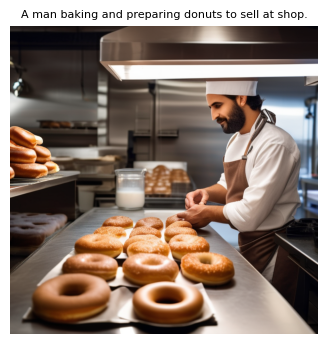

✅ Sanity OK


In [ ]:
def build_prompt(raw: str) -> str:
    return f"{raw.strip().rstrip('.')}, {F1_SUFFIX}"

@torch.inference_mode()
def generate_image(prompt: str, seed: int = SEED,
                   steps: int = NUM_STEPS,
                   guidance: float = GUIDANCE_SCALE,
                   size: int = IMAGE_SIZE) -> "Image":
    from PIL import Image as _Image
    gen = torch.Generator("cpu").manual_seed(seed)
    out = pipe(
        prompt=build_prompt(prompt),
        negative_prompt=NEGATIVE_PROMPT,
        num_inference_steps=steps,
        guidance_scale=guidance,
        height=size, width=size,
        generator=gen,
    )
    return out.images[0]

def generate_all(dataframe: pd.DataFrame, out_dir: Path) -> List[Optional[Path]]:
    """Generate all images. Skips existing files (resume support)."""
    from tqdm.auto import tqdm
    from PIL import Image as _Image
    out_dir.mkdir(parents=True, exist_ok=True)
    saved = []
    for i, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Generating"):
        path = out_dir / f"{row['prompt_id']}.png"
        if path.exists():
            saved.append(path); continue
        try:
            img = generate_image(row["prompt"], seed=SEED + i)
            img.save(path)
            saved.append(path)
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                torch.cuda.empty_cache(); gc.collect()
                print(f"\nOOM at {row['prompt_id']} — retrying 768px")
                try:
                    img = generate_image(row["prompt"], seed=SEED+i, size=768)
                    img.save(path); saved.append(path)
                except Exception as e2:
                    print(f"{row['prompt_id']}: {e2}"); saved.append(None)
            else:
                print(f"\n{row['prompt_id']}: {e}"); saved.append(None)
        if i % 5 == 4:
            torch.cuda.empty_cache(); gc.collect()
    return saved

# Sanity test (1 image, fast)
from PIL import Image as PILImage
print("Sanity test...")
test = generate_image(df["prompt"].iloc[0], steps=15, size=768)
test.save(LOCAL_OUT / "sanity.png")
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4)); plt.imshow(test); plt.axis("off")
plt.title(df["prompt"].iloc[0][:50], fontsize=8); plt.show()
print("Sanity OK")


In [ ]:
FINAL_DIR = LOCAL_OUT / "final"

print(f"Generating {len(df)} images | steps={NUM_STEPS} guidance={GUIDANCE_SCALE} size={IMAGE_SIZE}")
all_paths = generate_all(df, FINAL_DIR)

ok = sum(1 for p in all_paths if p and p.exists())
print(f"\nGenerated {ok}/{len(df)}")


Generating 49 images | steps=30 guidance=10.0 size=1024


Generating:   0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]


✅ Generated 49/49


In [ ]:
import shutil
from tqdm.auto import tqdm

print("Copying to Drive output/...")
copied = 0
for img in tqdm(sorted(FINAL_DIR.glob("*.png")), desc="→ Drive"):
    shutil.copy2(img, OUTPUT_DIR / img.name)
    copied += 1

shutil.copy2(DATA_DIR / "prompts.csv", OUTPUT_DIR / "prompts.csv")

print(f"\n {copied} images + prompts.csv saved to Drive")
print(f"   {OUTPUT_DIR}")
print()
print("━"*50)
print("Complete!")

Copying to Drive output/...


→ Drive:   0%|          | 0/49 [00:00<?, ?it/s]


✅ 49 images + prompts.csv saved to Drive
   /content/drive/MyDrive/text_to_image/output

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Part 1 complete!
  Now open Part 2 notebook for scoring + submission.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
